# Packages

In [1]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd

# Tensors debugging

In [2]:
name_smiles_embedding_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet")
morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet")
df5_subset = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet")
df5_spectra = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet")
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"


In [3]:
# Single dataset processing
dataset_name = "bin500_thresh100_df_spectra"  # Change this to your desired dataset
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print("Creating Group mapping from df5_spectra...")
id_to_group = dict(zip(df5_spectra['index_id'], df5_spectra['Group']))
print(f"Group mapping created with {len(id_to_group)} entries")

print(f"Processing single dataset: {dataset_name}")

try:
    # Load dataset from pickle file
    dataset_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    dataset = pd.read_pickle(dataset_path)

    # Convert to DataFrame if it's not already one
    if not isinstance(dataset, pd.DataFrame):
        dataset = pd.DataFrame(dataset)

    print(f"Loaded {dataset_name} - Shape: {dataset.shape}")
    
    # OPTIMIZATION 2: Efficient Group addition using copy() to avoid fragmentation
    if 'Group' not in dataset.columns:
        dataset = dataset.copy()  # Defragment DataFrame
        dataset['Group'] = dataset['index_id'].map(id_to_group).fillna('Unknown')
        print(f"Added Group column. Unique groups: {dataset['Group'].nunique()}")
        print(f"Group distribution: {dataset['Group'].value_counts().to_dict()}")
    else:
        print("Group column already exists in dataset")
    
    # Continue with your processing here...
    # Apply filtering
    counts = dataset['SMILES_spectra'].value_counts()
    valid_smiles = counts[counts >= 4].index
    filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()
    
    print(f"After filtering (>=4 spectra per SMILES): {filtered_dataset.shape}")
    
 
    
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

Creating Group mapping from df5_spectra...
Group mapping created with 3778 entries
Processing single dataset: bin500_thresh100_df_spectra
Loaded bin500_thresh100_df_spectra - Shape: (3778, 6)
Added Group column. Unique groups: 3
Group distribution: {'Q-Orbitrap-positive': 2122, 'Q-TOF-positive': 1498, 'LTQ-Orbitrap-positive': 158}
After filtering (>=4 spectra per SMILES): (3623, 7)


In [4]:
filtered_dataset.head()

,SMILES_spectra,250.0,750.0,index_id,Response,log_response,Group
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0,273.642508,5.611823,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,0.0,0.0,1,273.642508,5.611823,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,0.0,0.0,2,273.642508,5.611823,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,0.0,0.0,3,273.642508,5.611823,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,0.0,0.0,4,273.642508,5.611823,Q-Orbitrap-positive


In [5]:
def create_dataset_tensors_condenc_full(spectra_dataset, embedding_df, morgan_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors for the full conditional encoder WITH group information.
    
    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels with Group column
    embedding_df : pd.DataFrame
        DataFrame containing ChemNet embeddings for chemicals
    morgan_df : pd.DataFrame
        DataFrame containing Morgan fingerprints for chemicals
    device : torch.device
        The device (CPU or GPU) on which to store the tensors
    start_idx : int, optional
        Start index for spectral columns
    stop_idx : int, optional
        Stop index for spectral columns
    
    Returns:
    -------
    tuple
        A tuple containing:
        - spectra_with_group_tensor (torch.Tensor): Tensor of spectral data concatenated with one-hot encoded group
        - embeddings_tensor (torch.Tensor): Tensor of true ChemNet embeddings
        - log_tox_tensor (torch.Tensor): Tensor of log toxicity values
        - morgan_tensor (torch.Tensor): Tensor of Morgan fingerprints
        - spectra_indices_tensor (torch.Tensor): Tensor of indices
    """
    # Extract spectral data
    spectra = spectra_dataset.iloc[:, start_idx:stop_idx]
    
    # One-hot encode the Group column
    group_encoded = pd.get_dummies(spectra_dataset['Group'], prefix='group', dtype=int)
    print(group_encoded.head(5))
    # Concatenate spectra with group encoding
    spectra_with_group = pd.concat([spectra, group_encoded], axis=1)
    print(spectra_with_group.head(5))
    # Create chemical labels list
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    
    # Create tensors
    spectra_with_group_tensor = torch.Tensor(spectra_with_group.values).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    morgan_tensor = torch.Tensor([morgan_df.loc[morgan_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return spectra_with_group_tensor, embeddings_tensor, log_tox_tensor, morgan_tensor, spectra_indices_tensor


In [6]:
# Set device for tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# OPTIMIZATION 3: Vectorized train/test split (your custom method)
print("\n=== CUSTOM DATA SPLITTING ===")
smiles_groups = filtered_dataset.groupby('SMILES_spectra')
train_indices = []
test_indices = []

np.random.seed(42)
for smiles, group in smiles_groups:
    idx = group.index.values  # Use .values for faster access
    n = len(idx)
    np.random.shuffle(idx)
    split = n // 2
    test_indices.extend(idx[:split])
    train_indices.extend(idx[split:])

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add index column
train_data['index'] = range(len(train_data))
test_data['index'] = range(len(test_data))

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# OPTIMIZATION 4: Process both datasets together to avoid duplication
train_data_processed = fd.add_response_and_log_response(train_data.copy(), df5_subset, smiles_col='SMILES_spectra')
test_data_processed = fd.add_response_and_log_response(test_data.copy(), df5_subset, smiles_col='SMILES_spectra')

print(f"Train data processed shape: {train_data_processed.shape}")
print(f"Test data processed shape: {test_data_processed.shape}")

# Create tensors using the function
print("\n=== CREATING TENSORS ===")
print("Creating training tensors...")
x_train_with_group, y_train_emb, y_train_tox, y_train_morgan, train_indices_tensor = create_dataset_tensors_condenc_full(
    train_data_processed, name_smiles_embedding_df, morgan_df, device, start_idx=1, stop_idx=-5)

# print("Creating validation tensors...")
x_val_with_group, y_val_emb, y_val_tox, y_val_morgan, val_indices_tensor = create_dataset_tensors_condenc_full(
    test_data_processed, name_smiles_embedding_df, morgan_df, device, start_idx=1, stop_idx=-5)

# Print tensor shapes to verify
print(f"\n=== TENSOR SHAPES ===")
print(f"x_train_with_group: {x_train_with_group.shape}")
print(f"y_train_emb: {y_train_emb.shape}")
print(f"y_train_tox: {y_train_tox.shape}")
print(f"y_train_morgan: {y_train_morgan.shape}")
print(f"train_indices_tensor: {train_indices_tensor.shape}")

print(f"\nx_val_with_group: {x_val_with_group.shape}")
print(f"y_val_emb: {y_val_emb.shape}")
print(f"y_val_tox: {y_val_tox.shape}")
print(f"y_val_morgan: {y_val_morgan.shape}")
print(f"val_indices_tensor: {val_indices_tensor.shape}")

# View tensor contents/heads to verify structure
print(f"\n=== TENSOR STRUCTURE VERIFICATION ===")

print("\n--- x_train_with_group (first 3 samples, first 10 features) ---")
print(x_train_with_group[:3, :10])

print("\n--- y_train_emb (first 5 samples, first 10 embedding dimensions) ---")
print(y_train_emb[:5, :10])

print("\n--- y_train_tox (first 10 toxicity values) ---")
print(y_train_tox[:10])

print("\n--- y_train_morgan (first 3 samples, first 20 Morgan FP bits) ---")
print(y_train_morgan[:3, :20])

print("\n--- train_indices_tensor (first 10 indices) ---")
print(train_indices_tensor[:10])

# Check data types
print(f"\n=== TENSOR DATA TYPES ===")
print(f"x_train_with_group dtype: {x_train_with_group.dtype}")
print(f"y_train_emb dtype: {y_train_emb.dtype}")
print(f"y_train_tox dtype: {y_train_tox.dtype}")
print(f"y_train_morgan dtype: {y_train_morgan.dtype}")
print(f"train_indices_tensor dtype: {train_indices_tensor.dtype}")

# Check for NaN or infinite values
print(f"\n=== TENSOR QUALITY CHECK ===")
print(f"x_train_with_group - NaN count: {torch.isnan(x_train_with_group).sum().item()}")
print(f"y_train_emb - NaN count: {torch.isnan(y_train_emb).sum().item()}")
print(f"y_train_tox - NaN count: {torch.isnan(y_train_tox).sum().item()}")
print(f"y_train_morgan - NaN count: {torch.isnan(y_train_morgan).sum().item()}")

print(f"x_train_with_group - Inf count: {torch.isinf(x_train_with_group).sum().item()}")
print(f"y_train_emb - Inf count: {torch.isinf(y_train_emb).sum().item()}")
print(f"y_train_tox - Inf count: {torch.isinf(y_train_tox).sum().item()}")
print(f"y_train_morgan - Inf count: {torch.isinf(y_train_morgan).sum().item()}")

# Verify the data distribution is maintained
print(f"\n=== GROUP DISTRIBUTION CHECK ===")
print("Original filtered dataset:")
print(filtered_dataset['Group'].value_counts())
print("\nTraining data:")
print(train_data_processed['Group'].value_counts())
print("\nTest data:")
print(test_data_processed['Group'].value_counts())

# Additional verification - check value ranges
print(f"\n=== VALUE RANGES ===")
print(f"x_train_with_group - Min: {x_train_with_group.min().item():.4f}, Max: {x_train_with_group.max().item():.4f}")
print(f"y_train_emb - Min: {y_train_emb.min().item():.4f}, Max: {y_train_emb.max().item():.4f}")
print(f"y_train_tox - Min: {y_train_tox.min().item():.4f}, Max: {y_train_tox.max().item():.4f}")
print(f"y_train_morgan - Min: {y_train_morgan.min().item():.4f}, Max: {y_train_morgan.max().item():.4f}")

# DEBUGGING VISUALIZATION: Look at the data structure more closely
print(f"\n=== DETAILED TENSOR ANALYSIS ===")

# Look at specific samples to understand the structure
print("\n--- Sample 1 Analysis ---")
print(f"x_train_with_group[0] shape: {x_train_with_group[0].shape}")
print(f"x_train_with_group[0] first 20 values: {x_train_with_group[0][:20]}")

print(f"\ny_train_emb[0] shape: {y_train_emb[0].shape}")
print(f"y_train_emb[0] first 10 values: {y_train_emb[0][:10]}")

print(f"\ny_train_tox[0]: {y_train_tox[0]}")

print(f"\ny_train_morgan[0] shape: {y_train_morgan[0].shape}")
print(f"y_train_morgan[0] first 10 values: {y_train_morgan[0][:10]}")
print(f"y_train_morgan[0] sum (should be number of bits set): {y_train_morgan[0].sum()}")

print(f"\ntrain_indices_tensor[0]: {train_indices_tensor[0]}")

# Check what the spectral data looks like (x_train_with_group should contain spectra + group info)
print(f"\n=== SPECTRAL DATA STRUCTURE ===")
spectral_dim = x_train_with_group.shape[1] - 1  # Assuming last column is group
print(f"Spectral dimensions (excluding group): {spectral_dim}")
print(f"Group encoding (last column) first 10 samples: {x_train_with_group[:10, -1]}")

# Look at non-zero spectral values to verify data
sample_spectra = x_train_with_group[0, :-1]  # Exclude group column
non_zero_count = (sample_spectra > 0).sum()
print(f"Non-zero spectral values in first sample: {non_zero_count.item()}")
print(f"Max spectral value in first sample: {sample_spectra.max().item():.4f}")

# Verify correspondence between processed data and tensors
print(f"\n=== DATA CORRESPONDENCE CHECK ===")
print(f"First few SMILES in train_data_processed: {train_data_processed['SMILES_spectra'].head(3).tolist()}")
print(f"First few Response values in train_data_processed: {train_data_processed['Response'].head(3).tolist()}")
print(f"First few toxicity tensor values: {y_train_tox[:3].tolist()}")

Using device: cpu

=== CUSTOM DATA SPLITTING ===
Train data shape: (1862, 8)
Test data shape: (1761, 8)
Train data processed shape: (1862, 8)
Test data processed shape: (1761, 8)

=== CREATING TENSORS ===
Creating training tensors...
   group_LTQ-Orbitrap-positive  group_Q-Orbitrap-positive  \
0                            0                          1   
1                            0                          1   
2                            0                          1   
3                            0                          1   
4                            0                          1   

   group_Q-TOF-positive  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  
   250.0  750.0  group_LTQ-Orbitrap-positive  group_Q-Orbitrap-positive  \
0    0.0    0.0                            0                          1   
1    0.0    0.0                            0                          1   
2    0.0    0.0   

/tmp/ipykernel_335544/1632749609.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)


   group_LTQ-Orbitrap-positive  group_Q-Orbitrap-positive  \
0                            0                          1   
1                            0                          1   
2                            0                          1   
3                            0                          1   
4                            0                          1   

   group_Q-TOF-positive  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  
   250.0  750.0  group_LTQ-Orbitrap-positive  group_Q-Orbitrap-positive  \
0    0.0    0.0                            0                          1   
1    0.0    0.0                            0                          1   
2    0.0    0.0                            0                          1   
3    0.0    0.0                            0                          1   
4    0.0    0.0                            0                          1   

   group_Q-TOF-positive  


In [7]:
df = pd.read_pickle("/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs/cond_enc_full_bin1000_thresh100_df_spectra.pkl")
# df.head()
print(df.columns[510:516].tolist())

['cond_emb_510', 'cond_emb_511', 'cond_tox_pred', 'cond_morgan_0', 'cond_morgan_1', 'cond_morgan_2']


# Full Cond Enc Heatmap

/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/s

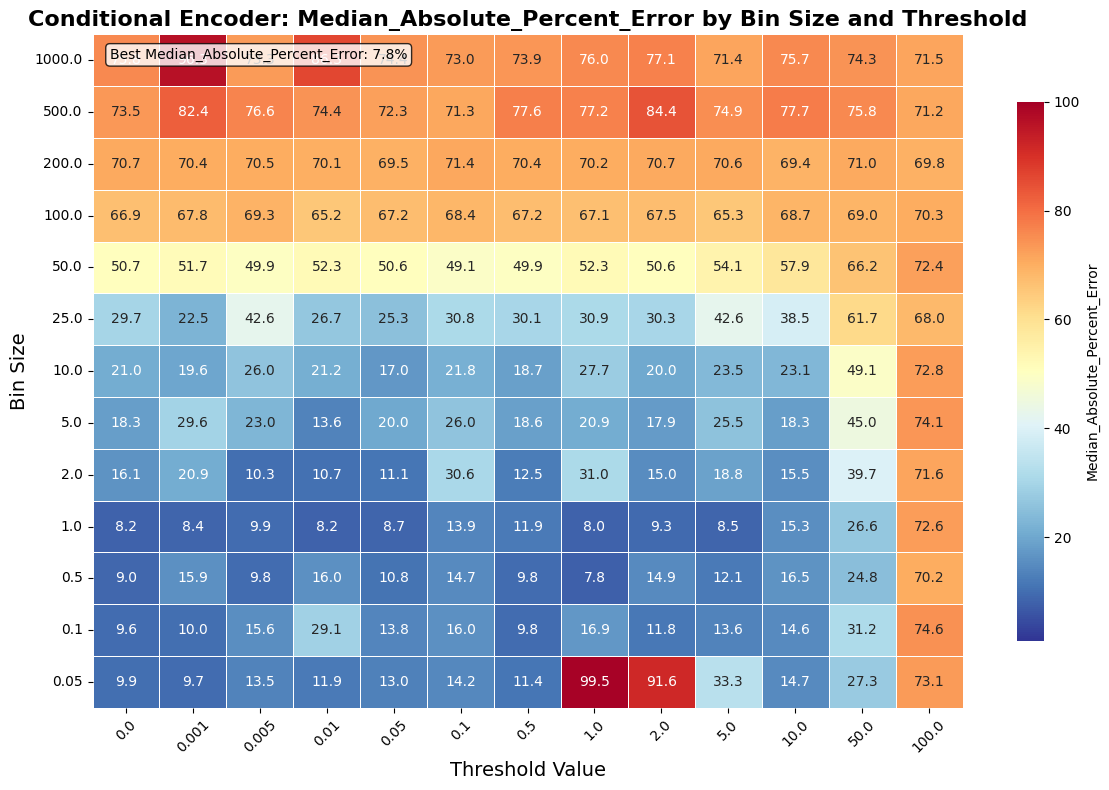

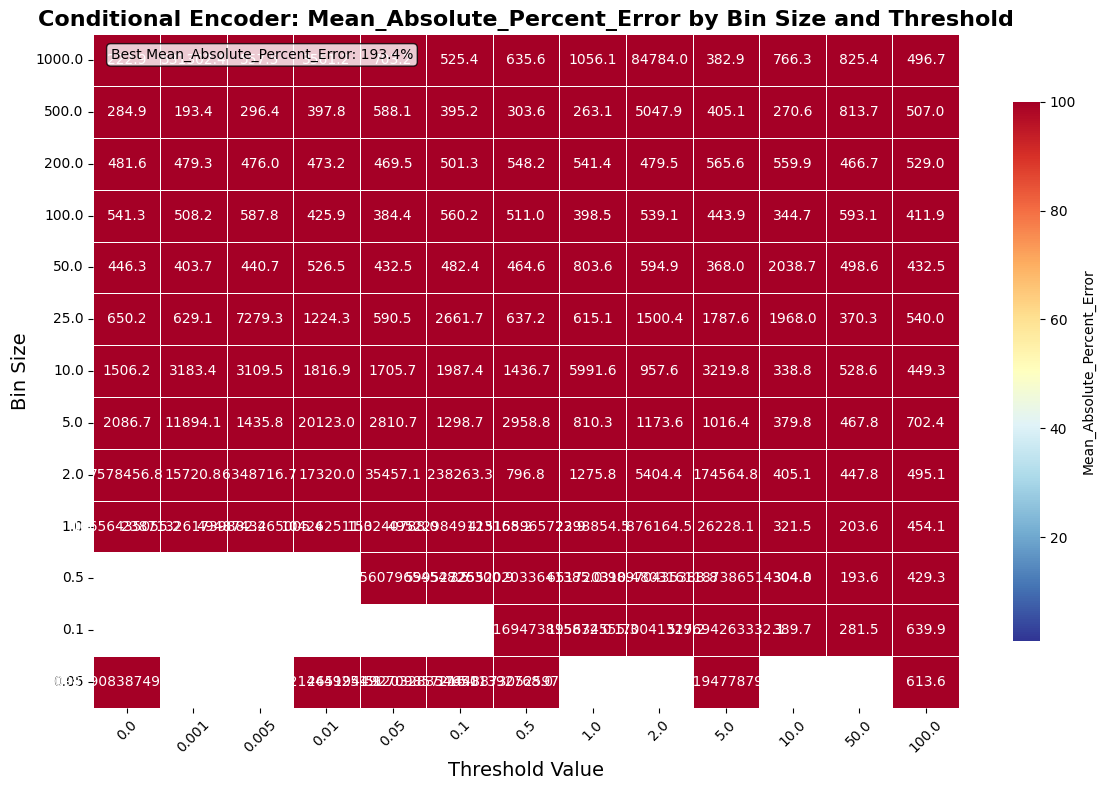

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load conditional encoder datasets folder path
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs"

# Get all .pkl files in the folder
cond_enc_pkl_files = [f for f in os.listdir(cond_enc_folder) if f.endswith('.pkl')]
cond_enc_dataset_names = [f.replace('.pkl', '') for f in cond_enc_pkl_files]

# Initialize storage for conditional encoder results (percent error only)
cond_enc_results_percent_error = []

# Process conditional encoder datasets
for i, dataset_name in enumerate(sorted(cond_enc_dataset_names), 1):
    try:
        # Load the conditional encoder dataset
        file_path = os.path.join(cond_enc_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            continue
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        # Store results
        cond_enc_results_percent_error.append({
            'Dataset': dataset_name,
            'Median_Percent_Error': median_percent_error,
            'Mean_Percent_Error': mean_percent_error,
            'Samples': len(y_pred_response_clean)
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
df_cond_enc_percent_error_results = pd.DataFrame(cond_enc_results_percent_error)

# Function to parse conditional encoder dataset names
def parse_cond_enc_dataset_name(dataset_name):
    """Extract bin size and threshold from full conditional encoder dataset name"""
    # Remove 'cond_enc_' prefix
    name_part = dataset_name.replace('cond_enc_full_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns
bin_sizes = []
thresholds = []

for dataset_name in df_cond_enc_percent_error_results['Dataset']:
    bin_size, threshold = parse_cond_enc_dataset_name(dataset_name)
    bin_sizes.append(bin_size)
    thresholds.append(threshold)

df_cond_enc_percent_error_results['BinSize'] = bin_sizes
df_cond_enc_percent_error_results['Threshold'] = thresholds

# Remove duplicates
df_cond_enc_percent_error_results = df_cond_enc_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

# Create pivot tables
cond_enc_median_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Median_Percent_Error')
cond_enc_mean_percent_error_pivot = df_cond_enc_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Mean_Percent_Error')

# List all expected thresholds and bin sizes
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables
cond_enc_median_percent_error_pivot = cond_enc_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
cond_enc_mean_percent_error_pivot = cond_enc_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Function to create heatmaps
def create_detailed_heatmap_cond_enc(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Conditional Encoder metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'{metric_name}', 'shrink': 0.8})
    
    plt.title(f'Conditional Encoder: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    best_val = pivot_data.min().min()
    plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
            transform=plt.gca().transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/CondEnc_{metric_name}_by_Bin_Size_and_Threshold.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()

# Create heatmaps
create_detailed_heatmap_cond_enc(cond_enc_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_cond_enc(cond_enc_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

### Heat Map single cell

In [9]:
def get_error_for_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs"):
    """
    Get mean and median absolute percent error for a specific bin size and threshold.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100)
    data_folder : str
        Path to the folder containing conditional encoder output files
        
    Returns:
    --------
    dict : Dictionary containing median_error, mean_error, and sample_count
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.pkl"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: File not found - {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the conditional encoder dataset
        df = pd.read_pickle(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            print(f"Warning: Only {len(y_pred_response_clean)} valid samples found")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        return {
            'bin_size': bin_size,
            'threshold': threshold,
            'median_error': median_percent_error,
            'mean_error': mean_percent_error,
            'sample_count': len(y_pred_response_clean),
            'dataset_name': dataset_name
        }
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Useage
# Get errors for bin size 100, threshold 1
result = get_error_for_dataset(bin_size=1, threshold=1)
if result:
    print(f"Dataset: {result['dataset_name']}")
    print(f"Bin Size: {result['bin_size']}")
    print(f"Threshold: {result['threshold']}")
    print(f"Median Absolute Percent Error: {result['median_error']:.1f}%")
    print(f"Mean Absolute Percent Error: {result['mean_error']:.1f}%")
    print(f"Sample Count: {result['sample_count']}")
else:
    print("Could not retrieve data for the specified parameters")

# You can also get errors for multiple datasets easily:
datasets_to_check = [
    (100, 1),
    (1000, 0),
    (0.1, 0.001),
    (50, 5),
    (10, 2),
    (200, 10),
    (0.5, 0.05)
]

print("\n" + "="*60)
print("MULTIPLE DATASET COMPARISON")
print("="*60)

for bin_size, threshold in datasets_to_check:
    result = get_error_for_dataset(bin_size, threshold)
    if result:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Median {result['median_error']:>5.1f}%, Mean {result['mean_error']:>5.1f}% (n={result['sample_count']})")
    else:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Data not available")

Dataset: cond_enc_full_bin1_thresh1_df_spectra
Bin Size: 1
Threshold: 1
Median Absolute Percent Error: 8.0%
Mean Absolute Percent Error: 2398854.5%
Sample Count: 3623

MULTIPLE DATASET COMPARISON
Bin  100, Thresh    1: Median  67.1%, Mean 398.5% (n=3623)
Bin 1000, Thresh    0: Median  75.8%, Mean 222.9% (n=3514)
Bin  0.1, Thresh 0.001: Median  10.0%, Mean   inf% (n=3623)
Bin   50, Thresh    5: Median  54.1%, Mean 368.0% (n=3623)
Bin   10, Thresh    2: Median  20.0%, Mean 957.6% (n=3623)
Bin  200, Thresh   10: Median  69.4%, Mean 559.9% (n=3623)
Bin  0.5, Thresh 0.05: Median  10.8%, Mean 3601856079654548.5% (n=3623)


/home/dlipsey/MITLincolnLabs/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Full Conditinal Encoder Super Test Set

In [27]:
def get_error_for_super_test_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_sets"):
    """
    Get mean and median absolute percent error for a specific bin size and threshold from super test set.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100)
    data_folder : str
        Path to the folder containing super test conditional encoder output files
        
    Returns:
    --------
    dict : Dictionary containing median_error, mean_error, and sample_count
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename for super test set
    dataset_name = f"super_test_cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.pkl"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: File not found - {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the super test conditional encoder dataset
        df = pd.read_pickle(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            print(f"Warning: Only {len(y_pred_response_clean)} valid samples found")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        return {
            'bin_size': bin_size,
            'threshold': threshold,
            'median_error': median_percent_error,
            'mean_error': mean_percent_error,
            'sample_count': len(y_pred_response_clean),
            'dataset_name': dataset_name
        }
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Usage examples for super test set
print("SUPER TEST SET CONDITIONAL ENCODER RESULTS")
print("=" * 50)

# Get errors for specific datasets
result = get_error_for_super_test_dataset(bin_size=1, threshold=1)
if result:
    print(f"Dataset: {result['dataset_name']}")
    print(f"Bin Size: {result['bin_size']}")
    print(f"Threshold: {result['threshold']}")
    print(f"Median Absolute Percent Error: {result['median_error']:.1f}%")
    print(f"Mean Absolute Percent Error: {result['mean_error']:.1f}%")
    print(f"Sample Count: {result['sample_count']}")
else:
    print("Could not retrieve data for the specified parameters")

# Check multiple super test datasets
datasets_to_check = [
    (100, 1),
    (1000, 0),
    (0.1, 0.001),
    (50, 5),
    (10, 2),
    (200, 10),
    (0.5, 0.05)
]

print("\n" + "="*60)
print("MULTIPLE SUPER TEST DATASET RESULTS")
print("="*60)

for bin_size, threshold in datasets_to_check:
    result = get_error_for_super_test_dataset(bin_size, threshold)
    if result:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Median {result['median_error']:>5.1f}%, Mean {result['mean_error']:>5.1f}% (n={result['sample_count']})")
    else:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Data not available")

SUPER TEST SET CONDITIONAL ENCODER RESULTS
Dataset: super_test_cond_enc_full_bin1_thresh1_df_spectra
Bin Size: 1
Threshold: 1
Median Absolute Percent Error: 222.5%
Mean Absolute Percent Error: 89554.5%
Sample Count: 109

MULTIPLE SUPER TEST DATASET RESULTS
Bin  100, Thresh    1: Median 128.0%, Mean 6970.2% (n=109)
Bin 1000, Thresh    0: Median  50.7%, Mean 2842.2% (n=109)
Bin  0.1, Thresh 0.001: Median 148.0%, Mean 42474.2% (n=109)
Bin   50, Thresh    5: Median  87.3%, Mean 18999.9% (n=109)
Bin   10, Thresh    2: Median  89.6%, Mean 14902.3% (n=109)
Bin  200, Thresh   10: Median 144.4%, Mean 5442.6% (n=109)
Bin  0.5, Thresh 0.05: Median 242.3%, Mean 279102.2% (n=109)


In [28]:
def get_error_for_super_test_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/super_test_sets", detailed_analysis=False):
    """
    Get mean and median absolute percent error for a specific bin size and threshold from super test set.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100)
    data_folder : str
        Path to the folder containing super test conditional encoder output files
    detailed_analysis : bool
        If True, provides detailed breakdown by SMILES with individual predictions
        
    Returns:
    --------
    dict : Dictionary containing median_error, mean_error, and sample_count
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename for super test set
    dataset_name = f"super_test_cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.pkl"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: File not found - {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the super test conditional encoder dataset
        df = pd.read_pickle(file_path)
        
        # Define super test SMILES for detailed analysis
        super_test_smiles = [
            'NC(=S)Nc1ccccc1',                                  # 6
            'COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1',   # 12
            'CCNc1nc(Cl)nc(NC(C)(C)C#N)n1',                     # 6 
            'C#CCN(C)Cc1ccccc1',                                # 6
            'COP(=S)(OC)Oc1ccc(SC)c(C)c1',                      # 6
            'Nc1cccc2c(N)cccc12',                               # 6
            'Cn1c(=O)c2c(ncn2CCO)n(C)c1=O',                     # 40
            'CNC(=O)N(C)c1nnc(C(C)(C)C)s1',                     # 6
            'Nc1ccc(Sc2ccc(N)cc2)cc1',                          # 15
            'COc1ccc2ccc(=O)oc2c1CC=C(C)C',                     # 6
        ]
        
        # Extract super test set
        super_test_df = df[df['SMILES_spectra'].isin(super_test_smiles)]
        
        # Get predictions and true values
        y_pred_log = super_test_df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = super_test_df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        super_test_df_clean = super_test_df[valid_mask].copy()
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:  # Skip if too few samples
            print(f"Warning: Only {len(y_pred_response_clean)} valid samples found")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate median and mean absolute percent error
        median_percent_error = np.median(individual_errors)
        mean_percent_error = np.mean(individual_errors)
        
        result = {
            'bin_size': bin_size,
            'threshold': threshold,
            'median_error': median_percent_error,
            'mean_error': mean_percent_error,
            'sample_count': len(y_pred_response_clean),
            'dataset_name': dataset_name
        }
        
        # If detailed analysis is requested, add comprehensive breakdown
        if detailed_analysis:
            print(f"Super test set size: {len(super_test_df)} samples")
            print(f"Super test SMILES found: {super_test_df['SMILES_spectra'].nunique()} unique SMILES")
            
            # Add predictions to dataframe
            super_test_df_clean['Predicted_Response'] = y_pred_response_clean.values
            super_test_df_clean['Individual_Error'] = individual_errors
            
            # === RESULTS ===
            print(f"\n=== SUPER TEST SET RESULTS ===")
            print(f"Super Test Median % Error: {median_percent_error:.1f}%")
            print(f"Super Test Mean % Error: {mean_percent_error:.1f}%")
            
            # === DETAILED BREAKDOWN BY SMILES ===
            print(f"\n=== DETAILED BREAKDOWN BY SMILES ===")
            
            # Group by SMILES and calculate statistics
            smiles_stats = super_test_df_clean.groupby('SMILES_spectra').agg({
                'Response': ['count', 'mean'],
                'Individual_Error': ['mean', 'median']
            }).round(1)
            
            smiles_stats.columns = ['Count', 'True_Response_Mean', 'Mean_Error', 'Median_Error']
            smiles_stats = smiles_stats.reset_index()
            
            print(f"{'SMILES':<50} {'Count':<6} {'True_Resp':<10} {'Mean_Err':<9} {'Med_Err':<8}")
            print("-" * 85)
            for _, row in smiles_stats.iterrows():
                smiles_short = row['SMILES_spectra'][:45] + "..." if len(row['SMILES_spectra']) > 45 else row['SMILES_spectra']
                print(f"{smiles_short:<50} {row['Count']:<6.0f} {row['True_Response_Mean']:<10.1f} {row['Mean_Error']:<9.1f}% {row['Median_Error']:<8.1f}%")
            
            # === DETAILED PREDICTIONS BY SMILES (ALL PREDICTIONS) ===
            print(f"\n=== DETAILED PREDICTIONS BY SMILES (ALL predictions per SMILES) ===")
            for smiles in super_test_smiles:
                smiles_data = super_test_df_clean[super_test_df_clean['SMILES_spectra'] == smiles]
                
                if len(smiles_data) > 0:
                    print(f"\nSMILES: {smiles}")
                    print(f"Total spectra: {len(smiles_data)}")
                    print(f"{'Index':<6} {'True_Response':<13} {'Pred_Response':<13} {'Error_%':<8}")
                    print("-" * 45)
                    
                    # Show ALL predictions
                    for i, (idx, pred_row) in enumerate(smiles_data.iterrows()):
                        print(f"{i+1:<6} {pred_row['Response']:<13.2f} {pred_row['Predicted_Response']:<13.2f} {pred_row['Individual_Error']:<8.1f}%")
                    
                    # Calculate and show summary statistics for this SMILES
                    print(f"\nSummary for {smiles}:")
                    print(f"  Min Error: {smiles_data['Individual_Error'].min():.1f}%")
                    print(f"  Max Error: {smiles_data['Individual_Error'].max():.1f}%")
                    print(f"  Mean Error: {smiles_data['Individual_Error'].mean():.1f}%")
                    print(f"  Median Error: {smiles_data['Individual_Error'].median():.1f}%")
                    print(f"  Std Error: {smiles_data['Individual_Error'].std():.1f}%")
                    
                else:
                    print(f"\nSMILES: {smiles} - NOT FOUND in dataset")
        
        return result
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Usage examples for super test set
print("SUPER TEST SET CONDITIONAL ENCODER RESULTS")
print("=" * 50)

# Get errors for bin_size=1, threshold=1 with detailed analysis
result = get_error_for_super_test_dataset(bin_size=1, threshold=1, detailed_analysis=True)
if result:
    print(f"\nDataset: {result['dataset_name']}")
    print(f"Bin Size: {result['bin_size']}")
    print(f"Threshold: {result['threshold']}")
    print(f"Sample Count: {result['sample_count']}")
else:
    print("Could not retrieve data for the specified parameters")

# Check multiple super test datasets (without detailed analysis)
datasets_to_check = [
    (100, 1),
    (1000, 0),
    (0.1, 0.001),
    (50, 5),
    (10, 2),
    (200, 10),
    (0.5, 0.05)
]

print("\n" + "="*60)
print("MULTIPLE SUPER TEST DATASET RESULTS")
print("="*60)

for bin_size, threshold in datasets_to_check:
    result = get_error_for_super_test_dataset(bin_size, threshold, detailed_analysis=False)
    if result:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Median {result['median_error']:>5.1f}%, Mean {result['mean_error']:>5.1f}% (n={result['sample_count']})")
    else:
        print(f"Bin {bin_size:>4}, Thresh {threshold:>4}: Data not available")

SUPER TEST SET CONDITIONAL ENCODER RESULTS
Super test set size: 109 samples
Super test SMILES found: 10 unique SMILES

=== SUPER TEST SET RESULTS ===
Super Test Median % Error: 222.5%
Super Test Mean % Error: 89554.5%

=== DETAILED BREAKDOWN BY SMILES ===
SMILES                                             Count  True_Resp  Mean_Err  Med_Err 
-------------------------------------------------------------------------------------
C#CCN(C)Cc1ccccc1                                  6      273.6      240.6    % 230.4   %
CCNc1nc(Cl)nc(NC(C)(C)C#N)n1                       6      218.5      1450.1   % 580.8   %
CNC(=O)N(C)c1nnc(C(C)(C)C)s1                       6      642.0      268.9    % 145.6   %
COP(=S)(OC)Oc1ccc(SC)c(C)c1                        6      180.0      260.1    % 168.5   %
COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc...   12     7.2        31924.0  % 19779.3 %
COc1ccc2ccc(=O)oc2c1CC=C(C)C                       6      2905.0     253.4    % 125.9   %
Cn1c(=O)c2c(ncn2CCO)n(C)c1=O  

# Error Distributions

Loading data for bin_size=1, threshold=1


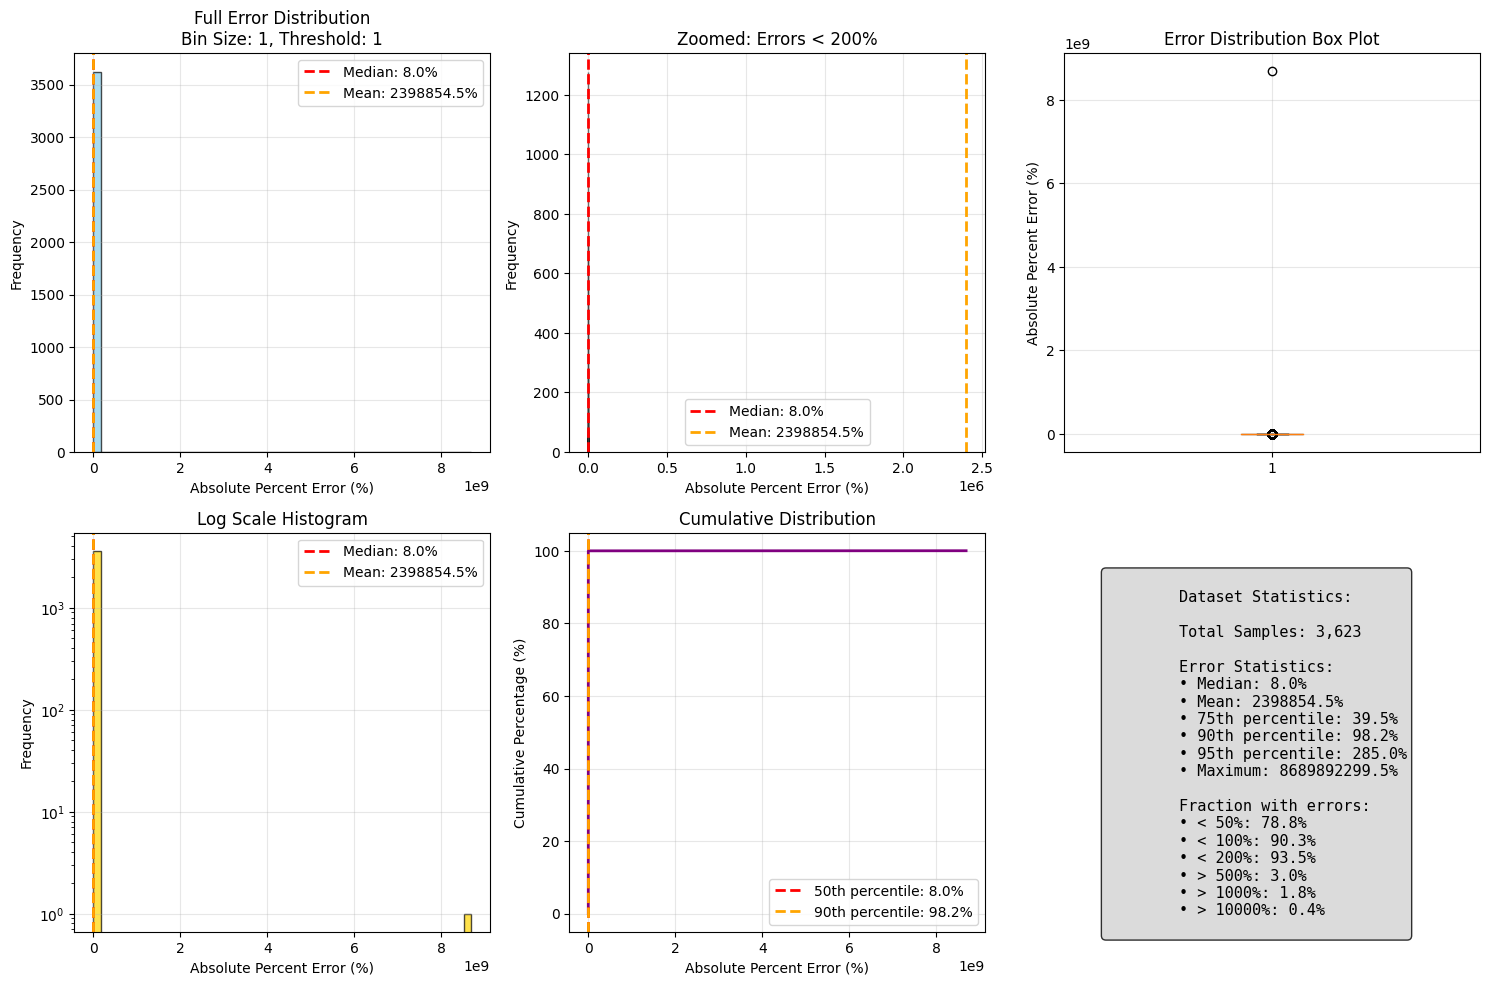


Outlier Analysis:
Number of outliers (>285.0%): 182 / 3623

Extreme Error Analysis:
Errors > 1000%: 64 / 3623 (1.77%)
Errors > 10000%: 15 / 3623 (0.41%)

Worst 20 predictions:
   1. True: 4390.000, Pred: 171740.922, Error:   3812.1%
   2. True: 4500.000, Pred: 202897.859, Error:   4408.8%
   3. True:   83.500, Pred: 3871.131, Error:   4536.1%
   4. True:   86.000, Pred: 5485.975, Error:   6279.0%
   5. True: 4197.111, Pred: 314367.688, Error:   7390.1%
   6. True:  500.000, Pred: 54250.793, Error:  10750.2%
   7. True:  129.667, Pred: 16026.062, Error:  12259.4%
   8. True: 7266.333, Pred: 931429.125, Error:  12718.4%
   9. True: 6400.000, Pred: 856981.750, Error:  13290.3%
  10. True:    2.667, Pred:  390.857, Error:  14557.1%
  11. True: 6400.000, Pred: 1163027.875, Error:  18072.3%
  12. True: 3000.000, Pred: 545351.438, Error:  18078.4%
  13. True:    7.210, Pred: 1369.450, Error:  18893.8%
  14. True:    7.210, Pred: 2740.603, Error:  37911.1%
  15. True: 14643.462, Pred: 6371497

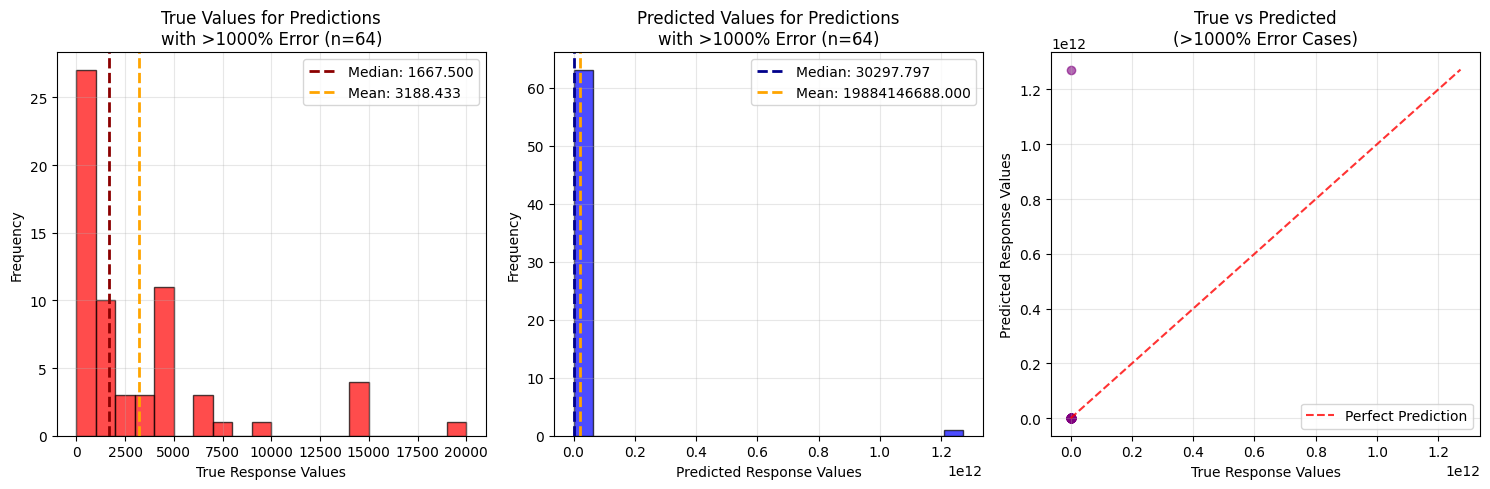


Statistics for predictions with >1000% error:
True values  - Min: 2.667, Max: 20000.000, Median: 1667.500, Mean: 3188.433
Pred values  - Min: 83.806, Max: 1272501108736.000, Median: 30297.797, Mean: 19884146688.000

Value range analysis for >1000% errors:
True values < 1: 0 / 64 (0.0%)
True values > 100: 52 / 64 (81.2%)


In [11]:
def plot_error_distribution_for_dataset(bin_size, threshold, data_folder="/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs"):
    """
    Generate a histogram showing the error distribution for a specific bin size and threshold.
    
    Parameters:
    -----------
    bin_size : float
        The bin size (e.g., 1, 5, 100, 1000)
    threshold : float  
        The threshold value (e.g., 0, 0.001, 0.1, 100)
    data_folder : str
        Path to the folder containing conditional encoder output files
    """
    
    # Convert bin_size and threshold to string format used in filenames
    if bin_size < 1:
        bin_str = f"bin{str(bin_size).replace('.', '_')}"
    else:
        bin_str = f"bin{int(bin_size)}"
    
    if threshold == 0:
        thresh_str = "thresh_zero"
    elif threshold < 1:
        thresh_str = f"thresh{str(threshold).replace('.', '_')}"
    else:
        thresh_str = f"thresh{int(threshold)}"
    
    # Construct filename
    dataset_name = f"cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
    filename = f"{dataset_name}.pkl"
    file_path = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(file_path):
        print(f"File not found: {filename}")
        print(f"Looking in: {data_folder}")
        return None
    
    try:
        # Load the data
        print(f"Loading data for bin_size={bin_size}, threshold={threshold}")
        df = pd.read_pickle(file_path)
        
        # Get predictions and true values
        y_pred_log = df['cond_tox_pred']  # Log predictions from conditional encoder
        y_true_response = df['Response']  # True toxicity values
        
        # Convert log predictions back to original scale
        y_pred_response = np.exp(y_pred_log)
        
        # Remove rows with NaN values
        valid_mask = ~(y_pred_log.isna() | y_true_response.isna())
        y_pred_response_clean = y_pred_response[valid_mask]
        y_true_response_clean = y_true_response[valid_mask]
        
        if len(y_pred_response_clean) < 10:
            print(f"Too few valid samples: {len(y_pred_response_clean)}")
            return None
        
        # Calculate absolute percent error on original scale (Response)
        individual_errors = np.abs((y_pred_response_clean - y_true_response_clean) / y_true_response_clean) * 100
        
        # Calculate statistics
        median_error = np.median(individual_errors)
        mean_error = np.mean(individual_errors)
        q75_error = np.percentile(individual_errors, 75)
        q90_error = np.percentile(individual_errors, 90)
        q95_error = np.percentile(individual_errors, 95)
        max_error = np.max(individual_errors)
        
        # Create the histogram plot
        plt.figure(figsize=(15, 10))
        
        # Main histogram (full range)
        plt.subplot(2, 3, 1)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title(f'Full Error Distribution\nBin Size: {bin_size}, Threshold: {threshold}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Zoomed histogram (errors < 200%)
        plt.subplot(2, 3, 2)
        errors_zoomed = individual_errors[individual_errors < 200]
        plt.hist(errors_zoomed, bins=40, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.title('Zoomed: Errors < 200%')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Box plot
        plt.subplot(2, 3, 3)
        plt.boxplot(individual_errors, patch_artist=True, 
                   boxprops=dict(facecolor='lightcoral', alpha=0.7))
        plt.ylabel('Absolute Percent Error (%)')
        plt.title('Error Distribution Box Plot')
        plt.grid(True, alpha=0.3)
        
        # Log scale histogram
        plt.subplot(2, 3, 4)
        plt.hist(individual_errors, bins=50, alpha=0.7, color='gold', edgecolor='black')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'Median: {median_error:.1f}%')
        plt.axvline(mean_error, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Frequency')
        plt.yscale('log')
        plt.title('Log Scale Histogram')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Cumulative distribution
        plt.subplot(2, 3, 5)
        sorted_errors = np.sort(individual_errors)
        cumulative_percent = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
        plt.plot(sorted_errors, cumulative_percent, linewidth=2, color='purple')
        plt.axvline(median_error, color='red', linestyle='--', linewidth=2, label=f'50th percentile: {median_error:.1f}%')
        plt.axvline(q90_error, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {q90_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)')
        plt.ylabel('Cumulative Percentage (%)')
        plt.title('Cumulative Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Statistics text
        plt.subplot(2, 3, 6)
        plt.axis('off')
        stats_text = f"""
        Dataset Statistics:
        
        Total Samples: {len(individual_errors):,}
        
        Error Statistics:
        • Median: {median_error:.1f}%
        • Mean: {mean_error:.1f}%
        • 75th percentile: {q75_error:.1f}%
        • 90th percentile: {q90_error:.1f}%
        • 95th percentile: {q95_error:.1f}%
        • Maximum: {max_error:.1f}%
        
        Fraction with errors:
        • < 50%: {(individual_errors < 50).mean()*100:.1f}%
        • < 100%: {(individual_errors < 100).mean()*100:.1f}%
        • < 200%: {(individual_errors < 200).mean()*100:.1f}%
        • > 500%: {(individual_errors > 500).mean()*100:.1f}%
        • > 1000%: {(individual_errors > 1000).mean()*100:.1f}%
        • > 10000%: {(individual_errors > 10000).mean()*100:.1f}%
        """
        plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print outlier information
        print(f"\nOutlier Analysis:")
        outlier_threshold = q95_error
        outliers = individual_errors > outlier_threshold
        print(f"Number of outliers (>{outlier_threshold:.1f}%): {outliers.sum()} / {len(individual_errors)}")
        
        # Print extreme outlier statistics
        print(f"\nExtreme Error Analysis:")
        print(f"Errors > 1000%: {(individual_errors > 1000).sum()} / {len(individual_errors)} ({(individual_errors > 1000).mean()*100:.2f}%)")
        print(f"Errors > 10000%: {(individual_errors > 10000).sum()} / {len(individual_errors)} ({(individual_errors > 10000).mean()*100:.2f}%)")
        
        # Show worst 20 predictions (instead of just 5)
        if len(individual_errors) > 0:
            print(f"\nWorst 20 predictions:")
            worst_indices = np.argsort(individual_errors)[-20:]
            for i, idx in enumerate(worst_indices):
                print(f"  {i+1:2d}. True: {y_true_response_clean.iloc[idx]:8.3f}, "
                      f"Pred: {y_pred_response_clean.iloc[idx]:8.3f}, "
                      f"Error: {individual_errors[idx]:8.1f}%")
        
        # Create histogram of true values for predictions with >1000% error
        extreme_error_mask = individual_errors > 1000
        if extreme_error_mask.sum() > 0:
            print(f"\nAnalyzing true values for {extreme_error_mask.sum()} predictions with >1000% error...")
            
            extreme_true_values = y_true_response_clean[extreme_error_mask]
            extreme_pred_values = y_pred_response_clean[extreme_error_mask]
            
            plt.figure(figsize=(15, 5))
            
            # Histogram of true values for extreme errors
            plt.subplot(1, 3, 1)
            plt.hist(extreme_true_values, bins=20, alpha=0.7, color='red', edgecolor='black')
            plt.xlabel('True Response Values')
            plt.ylabel('Frequency')
            plt.title(f'True Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_true_values), color='darkred', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_true_values):.3f}')
            plt.axvline(np.mean(extreme_true_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_true_values):.3f}')
            plt.legend()
            
            # Histogram of predicted values for extreme errors
            plt.subplot(1, 3, 2)
            plt.hist(extreme_pred_values, bins=20, alpha=0.7, color='blue', edgecolor='black')
            plt.xlabel('Predicted Response Values')
            plt.ylabel('Frequency')
            plt.title(f'Predicted Values for Predictions\nwith >1000% Error (n={extreme_error_mask.sum()})')
            plt.grid(True, alpha=0.3)
            
            # Add statistics
            plt.axvline(np.median(extreme_pred_values), color='darkblue', linestyle='--', 
                       linewidth=2, label=f'Median: {np.median(extreme_pred_values):.3f}')
            plt.axvline(np.mean(extreme_pred_values), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(extreme_pred_values):.3f}')
            plt.legend()
            
            # Scatter plot: True vs Predicted for extreme errors
            plt.subplot(1, 3, 3)
            plt.scatter(extreme_true_values, extreme_pred_values, alpha=0.6, color='purple')
            plt.xlabel('True Response Values')
            plt.ylabel('Predicted Response Values')
            plt.title('True vs Predicted\n(>1000% Error Cases)')
            plt.grid(True, alpha=0.3)
            
            # Add diagonal line
            min_val = min(extreme_true_values.min(), extreme_pred_values.min())
            max_val = max(extreme_true_values.max(), extreme_pred_values.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, label='Perfect Prediction')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
            # Print statistics for extreme error cases
            print(f"\nStatistics for predictions with >1000% error:")
            print(f"True values  - Min: {extreme_true_values.min():.3f}, Max: {extreme_true_values.max():.3f}, "
                  f"Median: {np.median(extreme_true_values):.3f}, Mean: {np.mean(extreme_true_values):.3f}")
            print(f"Pred values  - Min: {extreme_pred_values.min():.3f}, Max: {extreme_pred_values.max():.3f}, "
                  f"Median: {np.median(extreme_pred_values):.3f}, Mean: {np.mean(extreme_pred_values):.3f}")
            
            # Check if extreme errors are associated with specific value ranges
            print(f"\nValue range analysis for >1000% errors:")
            print(f"True values < 1: {(extreme_true_values < 1).sum()} / {len(extreme_true_values)} ({(extreme_true_values < 1).mean()*100:.1f}%)")
            print(f"True values > 100: {(extreme_true_values > 100).sum()} / {len(extreme_true_values)} ({(extreme_true_values > 100).mean()*100:.1f}%)")
        else:
            print(f"\nNo predictions with >1000% error found.")
        
        return individual_errors
        
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        return None

# Plot error distribution 
errors = plot_error_distribution_for_dataset(bin_size=1, threshold=1)

# Plot error distribution for bin size 1000, threshold 0 (no threshold)
# errors = plot_error_distribution_for_dataset(bin_size=1000, threshold=0)

# Plot error distribution for bin size 0.1, threshold 0.001
# errors = plot_error_distribution_for_dataset(bin_size=0.1, threshold=0.001)

# Conditional Encoder PCA

## ChemNet

Loading conditional encoder data: cond_enc_full_bin1_thresh1_df_spectra.pkl
SMILES with >= 4 spectra:
Found 391 SMILES with 4+ spectra
SMILES_spectra
Cc1cc(=O)n(-c2ccccc2)n1C                                           60
COc1c2ccoc2cc2oc(=O)ccc12                                          58
CNCCCN1c2ccccc2CCc2ccccc21                                         47
Cc1nc(NS(=O)(=O)c2ccc(N)cc2)oc1C                                   47
CC(C)(N)Cc1ccccc1                                                  47
Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1                                    47
CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC                                   45
CN(CC1(C)CCCO1)S(=O)(=O)c1ccc(Cl)c(S(N)(=O)=O)c1                   41
CC[C@@H](CO)NCCN[C@@H](CC)CO                                       41
C[C@H]1C(=O)O[C@@H]2CCN3CC=C(COC(=O)[C@](C)(O)[C@]1(C)O)[C@H]23    40
Name: count, dtype: int64
Filtered dataset shape: (3623, 2565)
Found 512 conditional encoder embedding columns
Sample column names: ['cond_emb_0', 'co

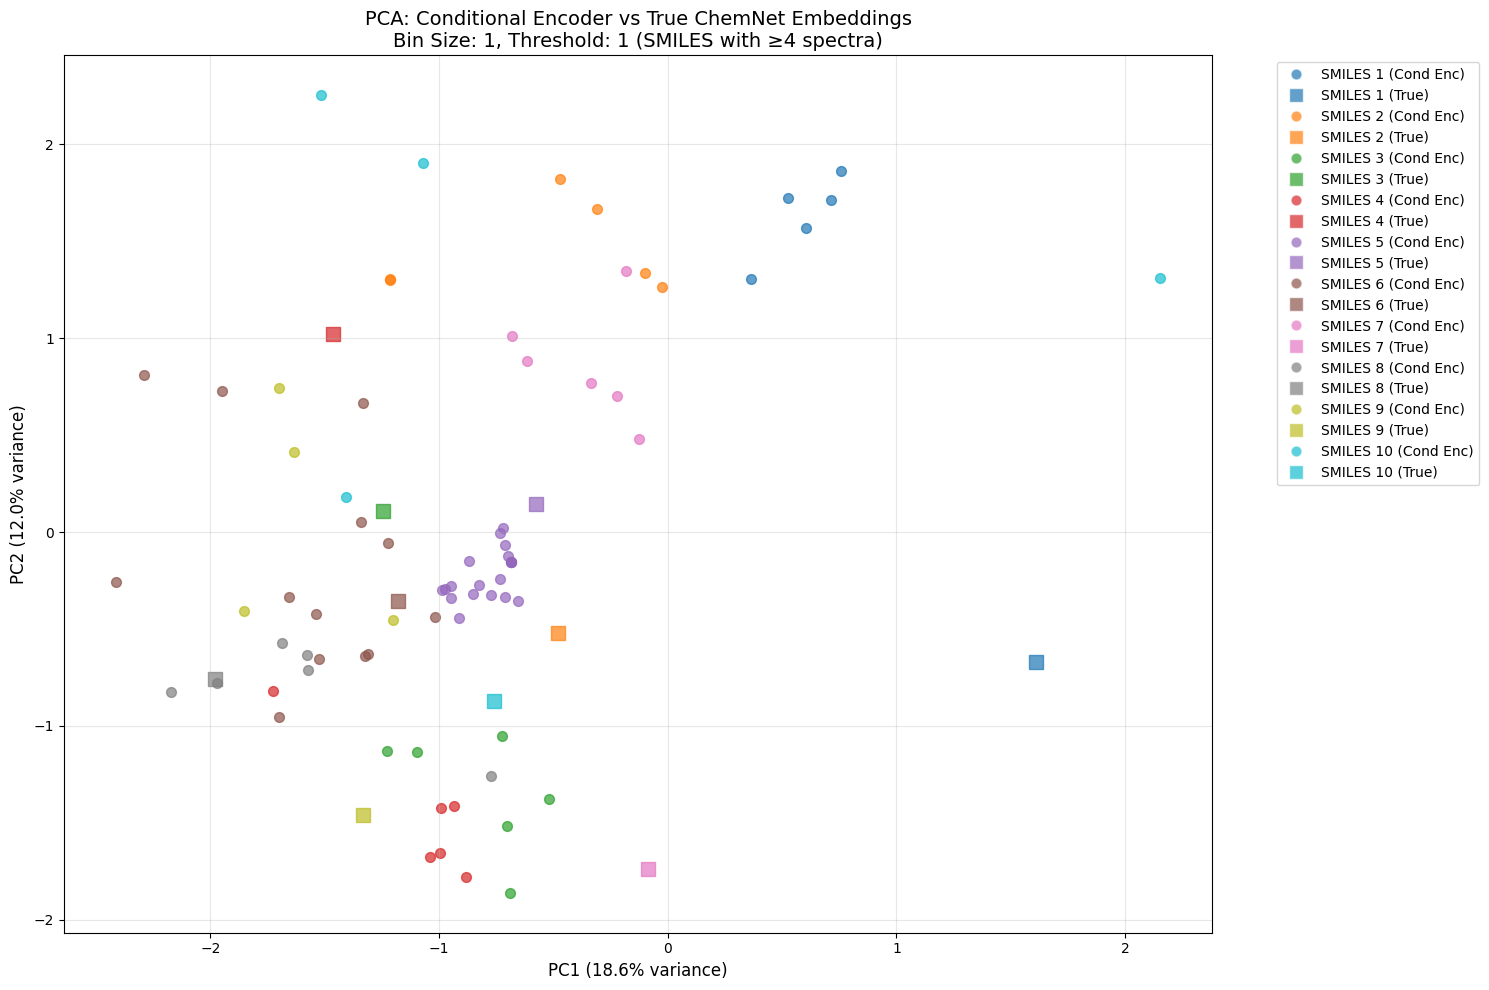


Conditional Encoder PCA explained variance: PC1=18.6%, PC2=12.0%
Conditional Encoder Total explained variance: 30.6%
True Embeddings PCA explained variance: PC1=7.6%, PC2=6.2%
True Embeddings Total explained variance: 13.8%


In [26]:
# Conditional Encoder PCA Analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Specify bin size and threshold for conditional encoder outputs
bin_size = 1  # Or other bin sizes like 10, 1000
threshold = 1   # Or other thresholds like 0, 5, 100

# Build filename for conditional encoder outputs
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs"

# Convert bin_size and threshold to string format used in filenames
if bin_size < 1:
    bin_str = f"bin{str(bin_size).replace('.', '_')}"
else:
    bin_str = f"bin{int(bin_size)}"

if threshold == 0:
    thresh_str = "thresh_zero"
elif threshold < 1:
    thresh_str = f"thresh{str(threshold).replace('.', '_')}"
else:
    thresh_str = f"thresh{int(threshold)}"

# Construct filename
dataset_name = f"cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
filename = f"{dataset_name}.pkl"
file_path = os.path.join(cond_enc_folder, filename)

print(f"Loading conditional encoder data: {filename}")
df = pd.read_pickle(file_path)

# Load the true ChemNet embeddings
df5_chemnet = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet")

# Set minimum number of spectra threshold (changeable)
min_spectra_count = 4  # Change this value as needed

# Count spectra per SMILES
smiles_counts = df['SMILES_spectra'].value_counts()
print(f"SMILES with >= {min_spectra_count} spectra:")
frequent_smiles = smiles_counts[smiles_counts >= min_spectra_count]
print(f"Found {len(frequent_smiles)} SMILES with {min_spectra_count}+ spectra")
print(frequent_smiles.head(10))

# Filter dataset to only include SMILES with sufficient spectra
df_filtered = df[df['SMILES_spectra'].isin(frequent_smiles.index)]
print(f"Filtered dataset shape: {df_filtered.shape}")

# Prepare features for PCA (conditional encoder embedding columns)
# Look for columns that start with 'cond_emb_' 
cond_emb_cols = [col for col in df_filtered.columns if col.startswith('cond_emb_')]
if len(cond_emb_cols) == 0:
    # Print available columns to help debug
    print("Available columns in conditional encoder data:")
    print([col for col in df_filtered.columns if 'emb' in col.lower()])
    print("First 10 columns:", df_filtered.columns[:10].tolist())
    print("Last 10 columns:", df_filtered.columns[-10:].tolist())
    raise ValueError("Could not find conditional encoder embedding columns")

print(f"Found {len(cond_emb_cols)} conditional encoder embedding columns")
print(f"Sample column names: {cond_emb_cols[:5]}")

X_cond = df_filtered[cond_emb_cols]

# Remove rows with NaN values
valid_mask_cond = ~X_cond.isna().any(axis=1)
X_cond_clean = X_cond[valid_mask_cond]
smiles_cond_clean = df_filtered.loc[valid_mask_cond, 'SMILES_spectra']

print(f"Conditional encoder embeddings shape after cleaning: {X_cond_clean.shape}")

# Perform PCA on conditional encoder embeddings
pca_cond = PCA(n_components=2, random_state=42)
X_cond_pca = pca_cond.fit_transform(X_cond_clean)

# Now get the true ChemNet embeddings for the same SMILES
unique_smiles_filtered = smiles_cond_clean.unique()
df5_chemnet_filtered = df5_chemnet[df5_chemnet['SMILES_spectra'].isin(unique_smiles_filtered)]

# Prepare true ChemNet embeddings for PCA
# Look for columns that start with 'emb_' in df5_chemnet
true_embedding_cols = [col for col in df5_chemnet_filtered.columns if col.startswith('emb_')]
if len(true_embedding_cols) == 0:
    # Fallback to the original column pattern if needed
    true_embedding_cols = [col for col in df5_chemnet_filtered.columns if col.startswith('Embedding Float')]

print(f"Found {len(true_embedding_cols)} true embedding columns")
print(f"Sample true embedding column names: {true_embedding_cols[:5]}")

X_true = df5_chemnet_filtered[true_embedding_cols]

# Remove rows with NaN values in true embeddings
valid_mask_true = ~X_true.isna().any(axis=1)
X_true_clean = X_true[valid_mask_true]
smiles_true_clean = df5_chemnet_filtered.loc[valid_mask_true, 'SMILES_spectra']

print(f"True ChemNet embeddings shape after cleaning: {X_true_clean.shape}")

# Perform PCA on true embeddings
pca_true = PCA(n_components=2, random_state=42)
X_true_pca = pca_true.fit_transform(X_true_clean)

# Create PCA plot colored by SMILES
plt.figure(figsize=(15, 10))

# Get unique SMILES and assign colors
unique_smiles = smiles_cond_clean.unique()
colors = plt.cm.tab10(np.linspace(0, 1, min(len(unique_smiles), 10)))

# Plot each SMILES group
for i, smiles in enumerate(unique_smiles[:10]):  # Limit to first 10 for visibility
    # Plot conditional encoder embeddings as circles
    mask_cond = smiles_cond_clean == smiles
    plt.scatter(X_cond_pca[mask_cond, 0], X_cond_pca[mask_cond, 1], 
               c=[colors[i]], label=f'SMILES {i+1} (Cond Enc)', alpha=0.7, s=50, marker='o')
    
    # Plot true embeddings as squares for the same SMILES
    mask_true = smiles_true_clean == smiles
    if np.any(mask_true):
        plt.scatter(X_true_pca[mask_true, 0], X_true_pca[mask_true, 1], 
                   c=[colors[i]], alpha=0.7, s=100, marker='s', 
                   label=f'SMILES {i+1} (True)' if i == 0 else "")

plt.xlabel(f'PC1 ({pca_cond.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_cond.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'PCA: Conditional Encoder vs True ChemNet Embeddings\nBin Size: {bin_size}, Threshold: {threshold} (SMILES with ≥{min_spectra_count} spectra)', fontsize=14)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []
for i in range(min(len(unique_smiles), 10)):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                                 markersize=8, label=f'SMILES {i+1} (Cond Enc)', alpha=0.7))
    legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=colors[i], 
                                 markersize=10, label=f'SMILES {i+1} (True)', alpha=0.7))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print explained variance information
print(f"\nConditional Encoder PCA explained variance: PC1={pca_cond.explained_variance_ratio_[0]:.1%}, PC2={pca_cond.explained_variance_ratio_[1]:.1%}")
print(f"Conditional Encoder Total explained variance: {pca_cond.explained_variance_ratio_.sum():.1%}")
print(f"True Embeddings PCA explained variance: PC1={pca_true.explained_variance_ratio_[0]:.1%}, PC2={pca_true.explained_variance_ratio_[1]:.1%}")
print(f"True Embeddings Total explained variance: {pca_true.explained_variance_ratio_.sum():.1%}")


## Morgan Fingerprint

Loading conditional encoder data: cond_enc_full_bin1_thresh1_df_spectra.pkl
SMILES with >= 4 spectra:
Found 391 SMILES with 4+ spectra
SMILES_spectra
Cc1cc(=O)n(-c2ccccc2)n1C                                           60
COc1c2ccoc2cc2oc(=O)ccc12                                          58
CNCCCN1c2ccccc2CCc2ccccc21                                         47
Cc1nc(NS(=O)(=O)c2ccc(N)cc2)oc1C                                   47
CC(C)(N)Cc1ccccc1                                                  47
Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1                                    47
CCN(CC)CCNC(=O)c1cc(Cl)c(N)cc1OC                                   45
CN(CC1(C)CCCO1)S(=O)(=O)c1ccc(Cl)c(S(N)(=O)=O)c1                   41
CC[C@@H](CO)NCCN[C@@H](CC)CO                                       41
C[C@H]1C(=O)O[C@@H]2CCN3CC=C(COC(=O)[C@](C)(O)[C@]1(C)O)[C@H]23    40
Name: count, dtype: int64
Filtered dataset shape: (3623, 2565)
Found 2048 conditional encoder Morgan fingerprint columns
Sample column names: ['cond_m

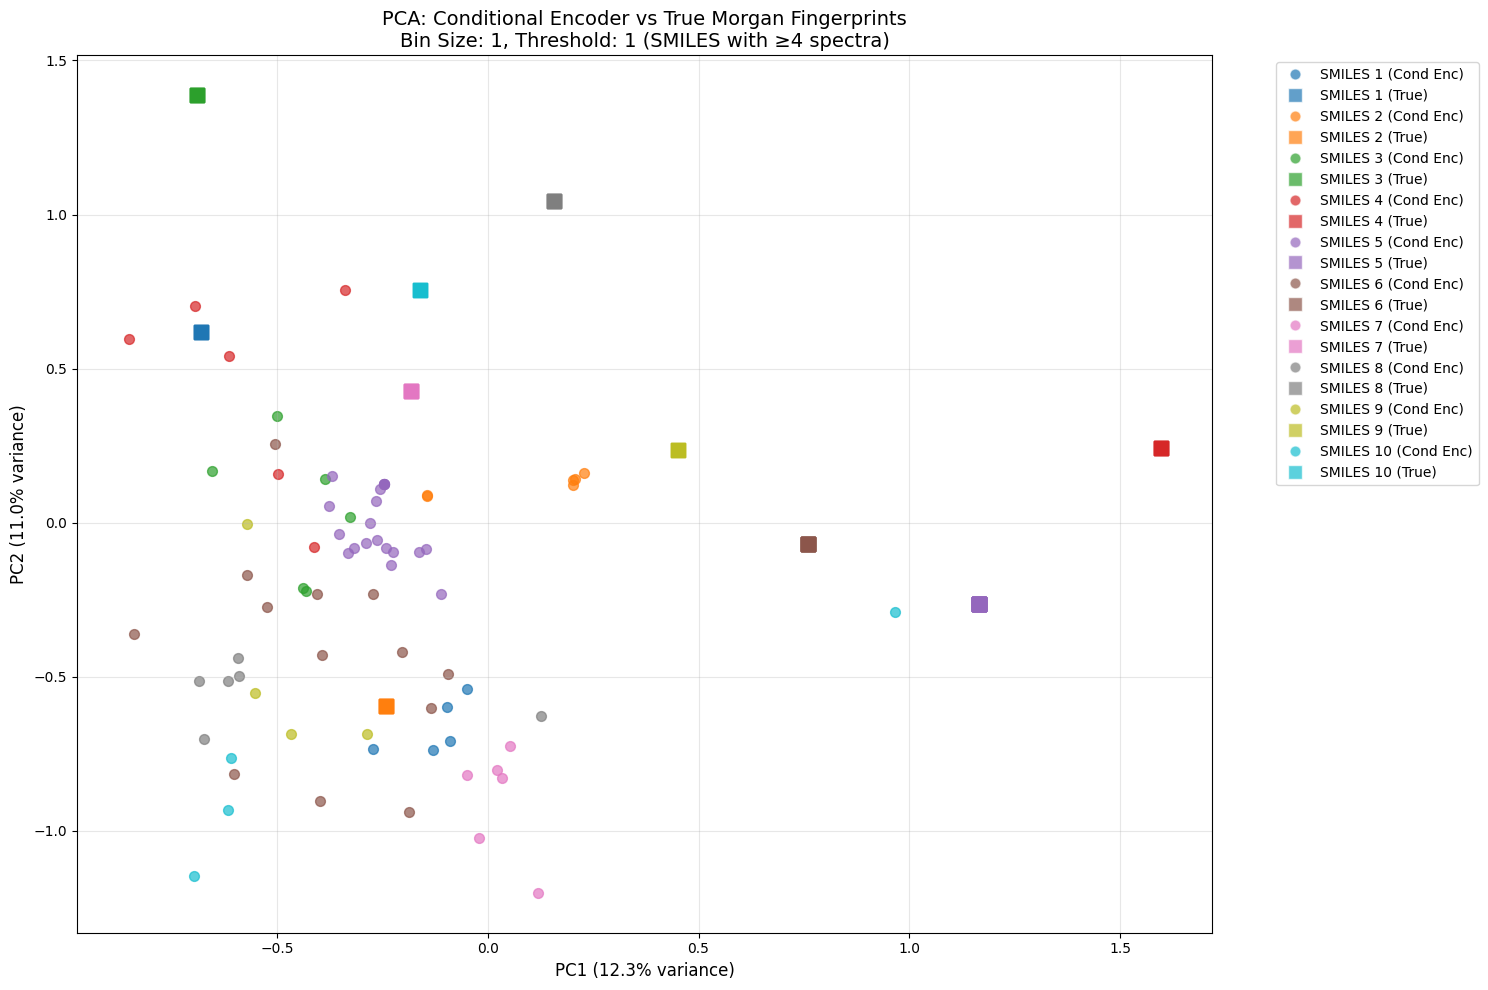


Conditional Encoder Morgan PCA explained variance: PC1=12.3%, PC2=11.0%
Conditional Encoder Morgan Total explained variance: 23.3%
True Morgan Fingerprints PCA explained variance: PC1=4.2%, PC2=3.7%
True Morgan Fingerprints Total explained variance: 7.9%

Analyzing correlation between conditional encoder and true Morgan fingerprints...


In [13]:
# Morgan Fingerprint PCA Analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Specify bin size and threshold for conditional encoder outputs
bin_size = 1  # Or other bin sizes like 10, 1000
threshold = 1   # Or other thresholds like 0, 5, 100

# Build filename for conditional encoder outputs
cond_enc_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/cond_enc_full_outputs"

# Convert bin_size and threshold to string format used in filenames
if bin_size < 1:
    bin_str = f"bin{str(bin_size).replace('.', '_')}"
else:
    bin_str = f"bin{int(bin_size)}"

if threshold == 0:
    thresh_str = "thresh_zero"
elif threshold < 1:
    thresh_str = f"thresh{str(threshold).replace('.', '_')}"
else:
    thresh_str = f"thresh{int(threshold)}"

# Construct filename
dataset_name = f"cond_enc_full_{bin_str}_{thresh_str}_df_spectra"
filename = f"{dataset_name}.pkl"
file_path = os.path.join(cond_enc_folder, filename)

print(f"Loading conditional encoder data: {filename}")
df = pd.read_pickle(file_path)

# Load the true Morgan fingerprints
morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet")

# Set minimum number of spectra threshold (changeable)
min_spectra_count = 4  # Change this value as needed

# Count spectra per SMILES
smiles_counts = df['SMILES_spectra'].value_counts()
print(f"SMILES with >= {min_spectra_count} spectra:")
frequent_smiles = smiles_counts[smiles_counts >= min_spectra_count]
print(f"Found {len(frequent_smiles)} SMILES with {min_spectra_count}+ spectra")
print(frequent_smiles.head(10))

# Filter dataset to only include SMILES with sufficient spectra
df_filtered = df[df['SMILES_spectra'].isin(frequent_smiles.index)]
print(f"Filtered dataset shape: {df_filtered.shape}")

# Prepare features for PCA (conditional encoder Morgan fingerprint columns)
# Look for columns that start with 'cond_morgan_' or similar pattern
cond_morgan_cols = [col for col in df_filtered.columns if col.startswith('cond_morgan_')]
if len(cond_morgan_cols) == 0:
    # Alternative patterns to look for
    cond_morgan_cols = [col for col in df_filtered.columns if 'morgan' in col.lower() and 'cond' in col.lower()]
    if len(cond_morgan_cols) == 0:
        # Print available columns to help debug
        print("Available columns in conditional encoder data:")
        print([col for col in df_filtered.columns if 'morgan' in col.lower()])
        print("First 10 columns:", df_filtered.columns[:10].tolist())
        print("Last 10 columns:", df_filtered.columns[-10:].tolist())
        raise ValueError("Could not find conditional encoder Morgan fingerprint columns")

print(f"Found {len(cond_morgan_cols)} conditional encoder Morgan fingerprint columns")
print(f"Sample column names: {cond_morgan_cols[:5]}")

X_cond_morgan = df_filtered[cond_morgan_cols]

# Remove rows with NaN values
valid_mask_cond = ~X_cond_morgan.isna().any(axis=1)
X_cond_morgan_clean = X_cond_morgan[valid_mask_cond]
smiles_cond_clean = df_filtered.loc[valid_mask_cond, 'SMILES_spectra']

print(f"Conditional encoder Morgan fingerprints shape after cleaning: {X_cond_morgan_clean.shape}")

# Perform PCA on conditional encoder Morgan fingerprints
pca_cond_morgan = PCA(n_components=2, random_state=42)
X_cond_morgan_pca = pca_cond_morgan.fit_transform(X_cond_morgan_clean)

# Now get the true Morgan fingerprints for the same SMILES
unique_smiles_filtered = smiles_cond_clean.unique()
morgan_df_filtered = morgan_df[morgan_df['SMILES_spectra'].isin(unique_smiles_filtered)]

# Prepare true Morgan fingerprints for PCA
# Look for Morgan fingerprint columns (should be numeric columns excluding SMILES)
true_morgan_cols = [col for col in morgan_df_filtered.columns if col != 'SMILES_spectra']
if len(true_morgan_cols) == 0:
    print("Available columns in Morgan fingerprint data:")
    print(morgan_df_filtered.columns.tolist())
    raise ValueError("Could not find true Morgan fingerprint columns")

print(f"Found {len(true_morgan_cols)} true Morgan fingerprint columns")
print(f"Sample true Morgan fingerprint column names: {true_morgan_cols[:5]}")

X_true_morgan = morgan_df_filtered[true_morgan_cols]

# Remove rows with NaN values in true Morgan fingerprints
valid_mask_true = ~X_true_morgan.isna().any(axis=1)
X_true_morgan_clean = X_true_morgan[valid_mask_true]
smiles_true_clean = morgan_df_filtered.loc[valid_mask_true, 'SMILES_spectra']

print(f"True Morgan fingerprints shape after cleaning: {X_true_morgan_clean.shape}")

# Perform PCA on true Morgan fingerprints
pca_true_morgan = PCA(n_components=2, random_state=42)
X_true_morgan_pca = pca_true_morgan.fit_transform(X_true_morgan_clean)

# Create PCA plot colored by SMILES
plt.figure(figsize=(15, 10))

# Get unique SMILES and assign colors
unique_smiles = smiles_cond_clean.unique()
colors = plt.cm.tab10(np.linspace(0, 1, min(len(unique_smiles), 10)))

# Plot each SMILES group
for i, smiles in enumerate(unique_smiles[:10]):  # Limit to first 10 for visibility
    # Plot conditional encoder Morgan fingerprints as circles
    mask_cond = smiles_cond_clean == smiles
    plt.scatter(X_cond_morgan_pca[mask_cond, 0], X_cond_morgan_pca[mask_cond, 1], 
               c=[colors[i]], label=f'SMILES {i+1} (Cond Enc)', alpha=0.7, s=50, marker='o')
    
    # Plot true Morgan fingerprints as squares for the same SMILES
    mask_true = smiles_true_clean == smiles
    if np.any(mask_true):
        plt.scatter(X_true_morgan_pca[mask_true, 0], X_true_morgan_pca[mask_true, 1], 
                   c=[colors[i]], alpha=0.7, s=100, marker='s', 
                   label=f'SMILES {i+1} (True)' if i == 0 else "")

plt.xlabel(f'PC1 ({pca_cond_morgan.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_cond_morgan.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'PCA: Conditional Encoder vs True Morgan Fingerprints\nBin Size: {bin_size}, Threshold: {threshold} (SMILES with ≥{min_spectra_count} spectra)', fontsize=14)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []
for i in range(min(len(unique_smiles), 10)):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
                                 markersize=8, label=f'SMILES {i+1} (Cond Enc)', alpha=0.7))
    legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor=colors[i], 
                                 markersize=10, label=f'SMILES {i+1} (True)', alpha=0.7))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print explained variance information
print(f"\nConditional Encoder Morgan PCA explained variance: PC1={pca_cond_morgan.explained_variance_ratio_[0]:.1%}, PC2={pca_cond_morgan.explained_variance_ratio_[1]:.1%}")
print(f"Conditional Encoder Morgan Total explained variance: {pca_cond_morgan.explained_variance_ratio_.sum():.1%}")
print(f"True Morgan Fingerprints PCA explained variance: PC1={pca_true_morgan.explained_variance_ratio_[0]:.1%}, PC2={pca_true_morgan.explained_variance_ratio_[1]:.1%}")
print(f"True Morgan Fingerprints Total explained variance: {pca_true_morgan.explained_variance_ratio_.sum():.1%}")

# Additional analysis: Calculate correlation between conditional encoder and true Morgan fingerprints
print(f"\nAnalyzing correlation between conditional encoder and true Morgan fingerprints...")

# Morgan Fingerpring Data Processing

In [14]:
# We are switching to the June 25 dataset
df4fp = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data4_fingerprints.csv")
print(df4fp.shape)
df4fp.head()

# Uniformity of ionization model labels
print(df4fp["Ionization_Mode"].unique())
df4fp["Ionization_Mode"] = df4fp["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df4fp["Ionization_Mode"].unique())
# Remove the N/A values in Ionization_Mode
df4fp = df4fp[df4fp["Ionization_Mode"] != "'N/A'"]
print(df4fp["Ionization_Mode"].unique())

# Remove single quotes from all string columns in df4
df4fp = df4fp.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# print(df4fp['Group'].nunique()) # 12
# # 12 groups
# print(df4fp['Group'].unique())
# # Now we want counts of each group
# print(df4fp['Group'].value_counts())

# This will give us the subsets with all of the relevant information
df4fp_QQpos = df4fp[df4fp['Group'] == 'Q-Orbitrap-positive'] # 2065

# Other groups with their sizes listed
# df4fp_QQneg = df4fp[df4fp['Group'] == 'Q-Orbitrap-negative'] # 1400
# df4fp_QTOFpos = df4fp[df4fp['Group'] == 'Q-TOF-positive'] # 1098
# df4fp_LTQOpos = df4fp[df4fp['Group'] == 'LTQ-Orbitrap-positive'] # 615

# All of the other are just too small to be all that useful with sizes from 12 to 286 associated spectra

# df4fp_QQpos.head()


(6121, 18)
["'positive'" "'negative'" "'Positive'" "'N/A'"]
["'positive'" "'negative'" "'N/A'"]
["'positive'" "'negative'"]


In [15]:
# # SMILES count (This is the number of true ChemNet embeddings we have)
# print(df4fp['SMILES_spectra'].nunique()) # 738 unique SMILES
# print(df4fp['SMILES_spectra'].value_counts()) # 69, 64, 58, 57, 51...

# # Morgan fingerprints count
# print(df4fp['fp'].nunique()) # 658 unique Morgan fingerprints
# print(df4fp['fp'].value_counts()) 

In [16]:
# df4fp_QQpos.head()

In [17]:
# Use the function
import function_depot as fd
df4fp_QQpos_matrix = fd.expand_fingerprints_to_matrix(df4fp_QQpos)
df4fp_QQpos_matrix = df4fp_QQpos_matrix.rename(columns={'SMILES': 'SMILES_spectra'})
df4fp_QQpos_matrix.head()

Created matrix with 2065 rows and 2048 fingerprint bits
Shape: (2065, 2049)


,SMILES_spectra,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,bit_2048
0,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# # Save the fingerprint matrix to CSV
# df4fp_QQpos_matrix.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/Morgan_fp_df4_QQpos.csv', index=False)
# print("Saved df4fp_QQpos_matrix to Morgan_fp_df4_QQpos.csv")

In [19]:
data = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh_zero_df_spectra.pkl')
data.head()

,SMILES_spectra,0.05,0.15000000000000002,0.25,0.35,0.44999999999999996,0.5499999999999999,0.6499999999999999,0.7499999999999999,0.8499999999999999,...,893.6500000001347,893.7500000001347,893.8500000001347,893.95,895.85,898.65,895.85,Response,log_response,index_id
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,1
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,2
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,3
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,4


In [20]:
# Training and validation dataset split for Morgan fingerprint encoder
data = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh_zero_df_spectra.pkl')
df4fp_QQpos_matrix = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/Morgan_fp_df4_QQpos.csv')

In [21]:
data.head()

,SMILES_spectra,0.05,0.15000000000000002,0.25,0.35,0.44999999999999996,0.5499999999999999,0.6499999999999999,0.7499999999999999,0.8499999999999999,...,893.6500000001347,893.7500000001347,893.8500000001347,893.95,895.85,898.65,895.85,Response,log_response,index_id
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,1
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,2
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,3
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,4


In [22]:
# Load the df4 dataset and check unique Response values
df4 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data4.csv")
print(f"Number of unique Response values in df4: {df4['Response'].nunique()}")

# Optional: Also show some statistics about the Response values
print(f"Response value range: {df4['Response'].min()} to {df4['Response'].max()}")
print(f"Total number of records: {len(df4)}")

Number of unique Response values in df4: 594
Response value range: 0.5 to 46965.46394
Total number of records: 6121


In [23]:
rand = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin50_thresh5_df_spectra.pkl')
rand.head()
print()

# Morgan Fingerprint RF

In [24]:
import os
import gc
import pickle

# Load Morgan fingerprint datasets folder path
morgan_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/morgan_enc_outputs"

# Get all .pkl files in the folder
morgan_pkl_files = [f for f in os.listdir(morgan_folder) if f.endswith('.pkl') and f.startswith('morgan_enc_')]
morgan_dataset_names = [f.replace('.pkl', '') for f in morgan_pkl_files]

print(f"Found {len(morgan_dataset_names)} Morgan fingerprint datasets to process")

# Verify we have the right count
morgan_thresh0_datasets = [name for name in morgan_dataset_names if 'thresh_zero' in name]
morgan_thresholded_datasets = [name for name in morgan_dataset_names if 'thresh_zero' not in name]

print(f"  - Morgan datasets with thresh0 (no threshold): {len(morgan_thresh0_datasets)}")
print(f"  - Morgan datasets with thresholds applied: {len(morgan_thresholded_datasets)}")

# Load the original dataset for response mapping
df4_QQpos = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df4_QQpos.csv")

# Initialize storage for Morgan results
morgan_results_r2 = []
morgan_results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_morgan_errors = {}

# Process Morgan fingerprint datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(morgan_dataset_names), 1):
    print(f"Processing {i}/{len(morgan_dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current Morgan dataset
        file_path = os.path.join(morgan_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Add response values by merging with original dataset
        df_with_response = df.merge(df4_QQpos[['SMILES_spectra', 'Response']], on='SMILES_spectra', how='left')
        
        # Add log response
        df_with_response['log_response'] = np.log(df_with_response['Response'])
        
        # Prepare features and target (Morgan fingerprint prediction columns are the features)
        feature_cols = [col for col in df.columns if col.startswith('morgan_fp_pred_')]
        X = df_with_response[feature_cols]
        y = df_with_response['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=47
        )
        
        # Train Random Forest with limited CPU usage
        rf_morgan = RandomForestRegressor(n_estimators=1, random_state=47, n_jobs=-1)
        rf_morgan.fit(X_train, y_train)

        # Make predictions
        y_train_pred = rf_morgan.predict(X_train)
        y_test_pred = rf_morgan.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_morgan_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        morgan_results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        morgan_results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'df_with_response' in locals():
            del df_with_response
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf_morgan' in locals():
            del rf_morgan
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_morgan_r2_results = pd.DataFrame(morgan_results_r2)
df_morgan_percent_error_results = pd.DataFrame(morgan_results_percent_error)

print(f"\nCompleted! Processed {len(morgan_results_r2)} Morgan fingerprint datasets successfully.")
print(f"Saved individual errors for {len(saved_morgan_errors)} datasets")
print(f"Results stored in: df_morgan_r2_results, df_morgan_percent_error_results")

Found 0 Morgan fingerprint datasets to process
  - Morgan datasets with thresh0 (no threshold): 0
  - Morgan datasets with thresholds applied: 0

Completed! Processed 0 Morgan fingerprint datasets successfully.
Saved individual errors for 0 datasets
Results stored in: df_morgan_r2_results, df_morgan_percent_error_results


In [25]:
# Create the actual heatmaps for Morgan fingerprint visualization
# First, let's extract bin size and threshold from the Morgan dataset names and add to results
def parse_morgan_dataset_name(dataset_name):
    """Extract bin size and threshold from Morgan dataset name"""
    # Remove 'morgan_enc_' prefix
    name_part = dataset_name.replace('morgan_enc_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to Morgan results DataFrames
for df_results in [df_morgan_r2_results, df_morgan_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_morgan_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in Morgan results...")
print(f"Original df_morgan_r2_results shape: {df_morgan_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_morgan_r2_results = df_morgan_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_morgan_percent_error_results = df_morgan_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_morgan_r2_results.shape}")

# Now create pivot tables for Morgan fingerprints
morgan_r2_pivot = df_morgan_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
morgan_median_percent_error_pivot = df_morgan_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
morgan_mean_percent_error_pivot = df_morgan_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
morgan_r2_pivot = morgan_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
morgan_median_percent_error_pivot = morgan_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
morgan_mean_percent_error_pivot = morgan_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for Morgan fingerprints for better detail
def create_detailed_heatmap_morgan(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Morgan fingerprint metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Morgan Fingerprint: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Morgan_Fingerprint_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual Morgan fingerprint heatmaps
print("Creating detailed Morgan fingerprint heatmaps...")

# create_detailed_heatmap_morgan(morgan_r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_morgan(morgan_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_morgan(morgan_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

KeyError: 'Dataset'